In [1]:
import networkx as nx
import numpy as np

def build_tracking_graph(P, threshold=0.1, top_k=5, 
                        birth_cost=0.0, death_cost=0.0):
    """
    P: (T-1, N, N, 3) probability matrix
    Returns: NetworkX graph ready for min-cost flow
    """
    T_deltas, N, _, _ = P.shape
    T = T_deltas + 1  # number of frames
    
    G = nx.DiGraph()
    G.add_node("source", demand=-(N*T))  # total possible cells
    G.add_node("sink", demand=N*T)
    
    # Add cell nodes
    for t in range(T):
        for i in range(N):
            G.add_node(f"cell_{t}_{i}", demand=0)
    
    # Birth edges (source to any frame)
    for t in range(T):
        for i in range(N):
            G.add_edge("source", f"cell_{t}_{i}", 
                      capacity=1, weight=birth_cost)
    
    # Tracking edges (between consecutive frames)
    for t in range(T-1):
        for i in range(N):
            # Get candidates above threshold
            candidates = []
            for j in range(N):
                p_cont = P[t, i, j, 1]
                if p_cont > threshold:
                    cost = -np.log(p_cont + 1e-10)
                    candidates.append((j, cost))
            
            # Keep top-k
            if top_k and len(candidates) > top_k:
                candidates.sort(key=lambda x: x[1])
                candidates = candidates[:top_k]
            
            # Add edges
            for j, cost in candidates:
                G.add_edge(f"cell_{t}_{i}", f"cell_{t+1}_{j}",
                          capacity=1, weight=cost)
    
    # Death edges (any frame to sink)
    for t in range(T):
        for i in range(N):
            G.add_edge(f"cell_{t}_{i}", "sink",
                      capacity=1, weight=death_cost)
    
    return G

def extract_tracks(G, flow_dict):
    """Extract cell tracks from flow solution"""
    tracks = []
    
    # Find all cells that receive flow from source (track starts)
    for node in flow_dict["source"]:
        if flow_dict["source"][node] > 0 and node != "sink":
            # Follow this track forward
            track = [node]
            current = node
            
            while current in flow_dict:
                # Find where flow goes from current node
                next_node = None
                for candidate in flow_dict.get(current, {}):
                    if flow_dict[current][candidate] > 0 and candidate != "sink":
                        next_node = candidate
                        break
                
                if next_node:
                    track.append(next_node)
                    current = next_node
                else:
                    break  # track ended
            
            tracks.append(track)
    
    return tracks

P = np.random.random((10, 10, 10, 3))
G = build_tracking_graph(P, threshold=0.99, top_k=2)
# flow_dict = nx.max_flow_min_cost(G, "source", "sink")
# tracks = extract_tracks(G, flow_dict)

In [3]:

def build_test_dataset(n_frames, starting_cells, prob_div = 0.4, wait_time = 4):

    curr_cells = starting_cells

    wait_mat = np.random.randint(0, 10, curr_cells)

    # Initialize first frame
    P = np.zeros((n_frames-1, curr_cells, curr_cells, 3))

    # No connection
    P[...,1] = 1

    # self connection
    P[0, :curr_cells, :curr_cells, 0] = np.eye(curr_cells, curr_cells)

    # parent/child connection
    P[0, :curr_cells, :curr_cells, 1] = 1 - P[0, :curr_cells, :curr_cells, 0]

    for i in range(1, n_frames-1):
        
        # Copy old cells

        P[i, ..., 0] = P[i-1, ..., 0]
        
        # New cells?

        if P[i-1,...,2].sum() > 0:
            
            col = np.argwhere(P[i-1, ..., 2])[:,1]
            P[i, col, col, 0] = 1
        
        P[i, ..., 1] = 1 - P[i,...,0] - P[i, ..., 2]

        eligible_cells = np.argwhere(wait_mat > wait_time)
        rn_mit = np.random.rand()

        if eligible_cells.size == 0:
            wait_mat += 1
            continue

        else:
            # mitosis is available
            random_mit_event = np.random.choice(eligible_cells.ravel())

            if rn_mit > 1-prob_div:

                P_savestate = P.copy()
                w_savestate = wait_mat.copy()

                P = np.zeros((n_frames-1, curr_cells+2, curr_cells+2, 3))
                P[..., 1] = 1
                wait_mat = np.zeros(curr_cells+2)
            
                P[:, :curr_cells, :curr_cells,] = P_savestate
                wait_mat[:curr_cells] = w_savestate
                
                # selected cell is dividing
                # increase size of array and copy for both P and wait_mat
                print("mitosis!")

                # mother dies
                P[i, random_mit_event, random_mit_event, 0] = 0

                P[i, random_mit_event, curr_cells:curr_cells+2, 2] = 1
                wait_mat[curr_cells:curr_cells+2] = 0
                
                curr_cells += 2


        print("number of cells:", P.shape[1])
    return P
    

In [4]:
P = build_test_dataset(10, 10)

number of cells: 10
mitosis!
number of cells: 12
mitosis!
number of cells: 14
number of cells: 14
mitosis!
number of cells: 16
mitosis!
number of cells: 18
number of cells: 18
mitosis!
number of cells: 20


In [30]:
P.shape

np.save('temporal_adjacency.npy', P)

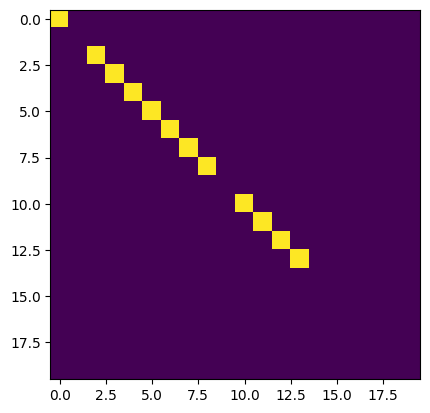

In [28]:
import matplotlib.pyplot as plt

plt.imshow(P[4,...,0])

In [ ]:
def build_tracking_graph(P, threshold=0.1, top_k=2):
    """
    P: (T-1, N, N, 3) probability matrix
    Returns: NetworkX graph ready for min-cost flow
    """
    T_deltas, N, _, _ = P.shape
    T = T_deltas + 1  # number of frames
    
    G = nx.DiGraph()
    
    # Add cell nodes
    for t in range(T):
        for i in range(N):
            G.add_node(f"cell_{t}_{i}", demand=0)
    
    # Tracking edges (between consecutive frames)
    for t in range(T-1):
        for i in range(N):
            # Get candidates above threshold
            candidates = []
            for j in range(N):
                p_cont = P[t, i, j, 0]
                if p_cont > threshold:
                    cost = -np.log(p_cont + 1e-10)
                    candidates.append((j, cost))
            
            # Keep top-k
            if top_k and len(candidates) > top_k:
                candidates.sort(key=lambda x: x[1])
                candidates = candidates[:top_k]
            
            # Add edges
            for j, cost in candidates:
                G.add_edge(f"cell_{t}_{i}", f"cell_{t+1}_{j}",
                          capacity=1, weight=cost)
    
    return G

In [ ]:
# G = build_tracking_graph(P, top_k=1)
# print(G)
# G_sub = nx.subgraph(G, nbunch={'cell_1_1'}.update(nx.descendants(G, 'cell_1_1')))
# print(G_sub)
# pos = nx.bfs_layout(G_sub, 'cell_1_1')

nx.simple_cycles(G)

StopIteration: 

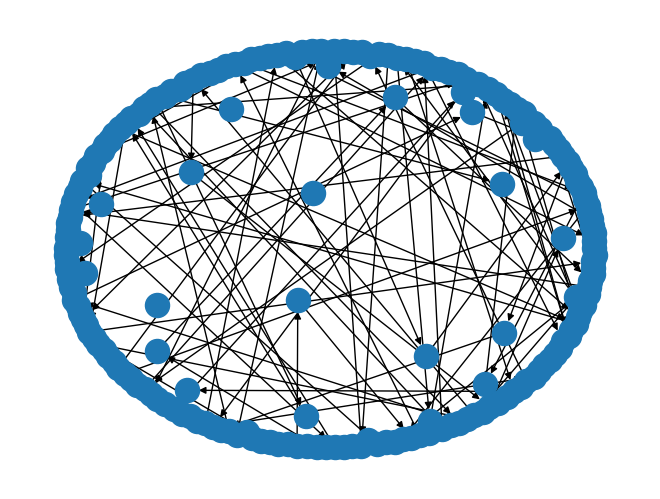

In [13]:
pos = nx.spring_layout(G, iterations=1000)
nx.draw(G, pos=pos)

In [ ]:
import pandas as pd
import networkx as nx
import networkx_temporal as tx

def trk_to_graph(lineage, node_key=None):
    """Converts a lineage dictionary into a graph representation of the lineages

    Args:
        lineage (dict): Dictionary of lineage data
        node_key (dict): Map between gt nodes and result nodes

    Returns:
        networkx.Graph: Graph representation of the lineage data.
    """
    edges = []

    all_ids = set()
    single_nodes = set()
    attributes = {}

    for i, lin in lineage.items():
        # Update cell id if node_key is available
        if node_key and (i in node_key):
            idx = node_key[i]
        else:
            idx = i

        layers = [t for t in lin['frames']]
        cellids = ['{}_{}'.format(idx, t) for t in lin['frames']]

        if len(cellids) == 1:
            single_nodes.add(cellids[0])

        all_ids.update(cellids)
        edges.append(pd.DataFrame({
            'source': cellids[0:-1],
            'target': cellids[1:],
        }))

        print(edges)

        # Add connections to any daughters
        source = '{}_{}'.format(idx, max(lin['frames']))
        for d in lin['daughters']:
            # Update cell id if node_key is available
            if node_key and (i in node_key):
                d_idx = node_key[d]
            else:
                d_idx = d

            # Assume daughter appears in next frame
            target = '{}_{}'.format(d_idx, max(lin['frames']) + 1)
            edges.append(pd.DataFrame({
                'source': [source],
                'target': [target]
            }))

            attributes[source] = {'division': True}

    # Create graph
    edges = pd.concat(edges)
    G = nx.from_pandas_edgelist(edges, source='source', target='target', create_using=nx.DiGraph)
    nx.set_node_attributes(G, attributes)

    # Add all isolates to graph
    for cell_id in single_nodes:
        G.add_node(cell_id)

    return G

In [26]:
g = trk_to_graph(lineage=lin[0])

[   source target
0     1_0    1_1
1     1_1    1_2
2     1_2    1_3
3     1_3    1_4
4     1_4    1_5
5     1_5    1_6
6     1_6    1_7
7     1_7    1_8
8     1_8    1_9
9     1_9   1_10
10   1_10   1_11
11   1_11   1_12
12   1_12   1_13
13   1_13   1_14
14   1_14   1_15
15   1_15   1_16
16   1_16   1_17
17   1_17   1_18
18   1_18   1_19
19   1_19   1_20
20   1_20   1_21
21   1_21   1_22
22   1_22   1_23
23   1_23   1_24
24   1_24   1_25
25   1_25   1_26
26   1_26   1_27
27   1_27   1_28
28   1_28   1_29
29   1_29   1_30
30   1_30   1_31
31   1_31   1_32
32   1_32   1_33
33   1_33   1_34
34   1_34   1_35
35   1_35   1_36
36   1_36   1_37
37   1_37   1_38
38   1_38   1_39
39   1_39   1_40
40   1_40   1_41]
[   source target
0     1_0    1_1
1     1_1    1_2
2     1_2    1_3
3     1_3    1_4
4     1_4    1_5
5     1_5    1_6
6     1_6    1_7
7     1_7    1_8
8     1_8    1_9
9     1_9   1_10
10   1_10   1_11
11   1_11   1_12
12   1_12   1_13
13   1_13   1_14
14   1_14   1_15
15   1_15  

In [1]:
import zarr

z = zarr.open('data/DynamicNuclearNet-tracking-v1_0/test.zarr')

lin = z['lineages'][0]

In [6]:
import pandas as pd
import networkx as nx
import networkx_temporal as tx

def trk_to_graph(lineage, node_key=None):
    """Converts a lineage dictionary into a graph representation of the lineages

    Args:
        lineage (dict): Dictionary of lineage data
        node_key (dict): Map between gt nodes and result nodes

    Returns:
        networkx.Graph: Graph representation of the lineage data.
    """

    tg = tx.TemporalDiGraph()

    for i, lin in lineage.items():
        print(lin['frames'])

        for t in lin['frames']:
            tg.add_edge(i, i, time=t) 

        # Add connections to any daughters
        for d in lin['daughters']:
            tg.add_edge(i, d, time=max(lin['frames']))

    return tg

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,

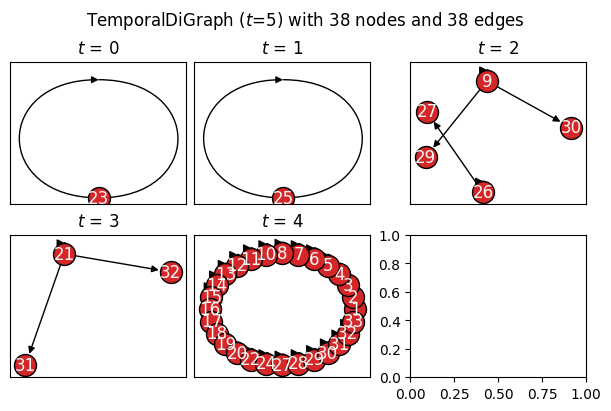

In [7]:
import matplotlib.pyplot as plt


g = trk_to_graph(lineage=lin[0])
g = g.slice(attr='time')
tx.draw(g,
              layout="kamada_kawai",
              figsize=(6, 4),
              nrows=2,
              ncols=3,
              border=True,
              suptitle=True)